In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

In [45]:
idxs = np.array([x for x in np.arange(0, 21) if x != 3])

In [46]:
final_conductance = []
for idx in idxs:
    results = pd.read_csv(f"output/temporal-interference/subthreshold_conductance2/{idx}_results.csv")
    if not results.iloc[-1].Correct:
        print(f"Did not converge for {idx}")
    final_conductance.append(results.iloc[-1].Conductance)

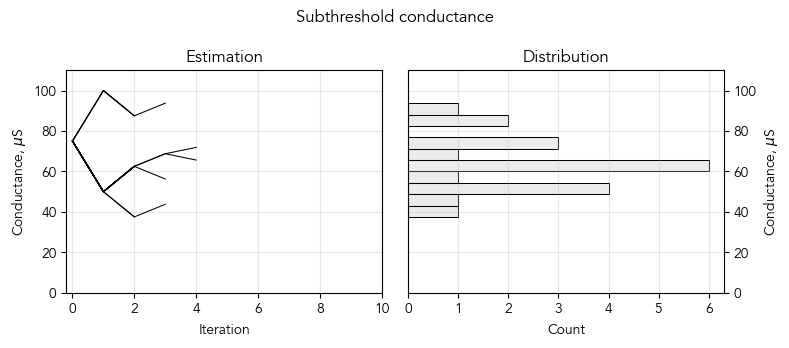

In [47]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 3.5))

for idx in idxs:
    results = pd.read_csv(f"output/temporal-interference/subthreshold_conductance2/{idx}_results.csv")

    axs[0].plot(
        results.index,
        results.Conductance * 1000_000,
        linewidth = 0.75,
        color = "black"
    )

axs[0].set_xlabel("Iteration")
axs[0].set_ylabel(r"Conductance, $\mu$S")
axs[0].set_ylim(0, 0.00011 * 1000_000)
axs[0].set_title("Estimation")
axs[0].grid(True, alpha = 0.3)
axs[0].set_xticks(range(0, 12, 2))

axs[1].hist(np.array(final_conductance) * 1000_000, bins = 10, orientation = "horizontal", facecolor = (0, 0, 0, 0.075), edgecolor = "black", linewidth = 0.75)
axs[1].set_ylabel(r"Conductance, $\mu$S")
axs[1].set_xlabel("Count")
axs[1].set_title("Distribution")
axs[1].set_ylim(0, 110)
axs[1].grid(True, alpha = 0.3)
axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()

fig.suptitle("Subthreshold conductance")
fig.tight_layout()
plt.show()

Subthreshold conductance was estimated in such a way that there would be no action potentials before or after LTP induction but the neuron would fire during the LTP induction protocol. Some synapse configurations seem to be more sensitive than others (they require more iterations to find such conductance because the neuron either spikes after LTP or does not spike during LTP). **These configurations are more likely to result in a post-LTP spike in TI conditions.**

In [48]:
for idx in idxs:
    conductance1 = pd.read_csv(f"output/temporal-interference/subthreshold_conductance2/{idx}.txt", header = None).iloc[0][0]
    conductance2 = pd.read_csv(f"output/temporal-interference/subthreshold_conductance2/{idx}_results.csv").iloc[-1].Conductance
    
    assert conductance1 == conductance2

In [49]:
test_stimulus_1 = 100
test_stimulus_2 = 2500
time_before = 50
time_after = 100

ltp_start = 1000
ltp_duration = 1000

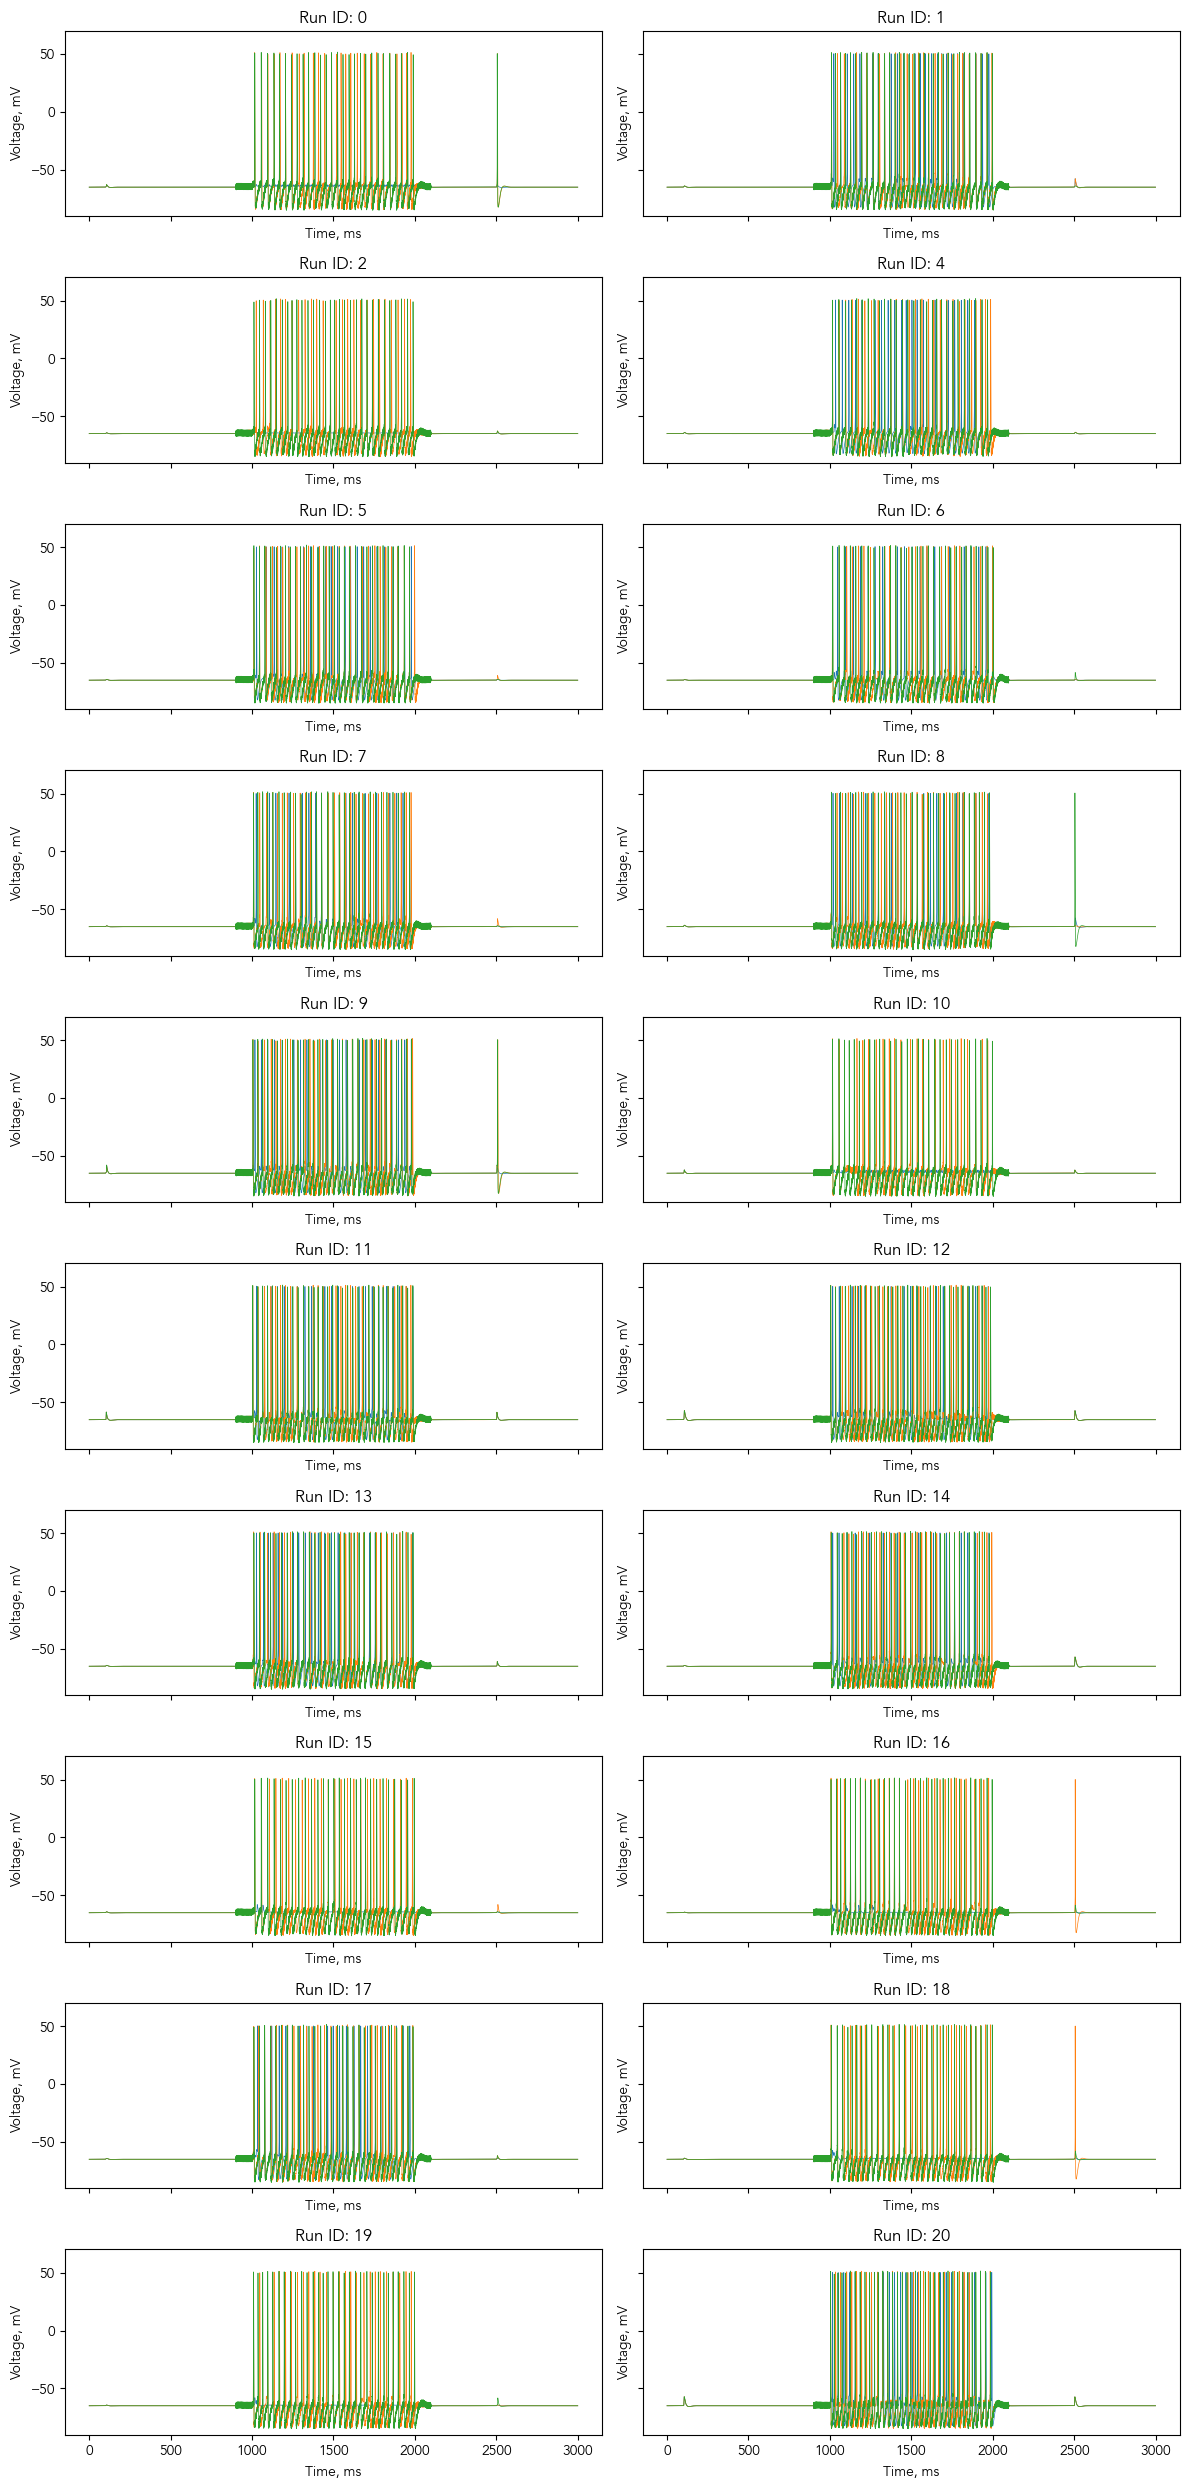

In [62]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 2), ncols = 2, figsize = (12, int(len(idxs) / 2) * 2.5), sharey = True, sharex = True)
axs = axs.flatten()

no_ap_after = []
for idx, ax in zip(idxs, axs):
    try:
        voltage = pd.read_csv(f"output/temporal-interference/subthreshold_conductance_ltp_trace2/{idx}/voltage.csv")
        # voltage0 = pd.read_csv(f"output/temporal-interference/subthreshold_conductance_ltp_trace_0Hz2/{idx}/voltage.csv")
        voltage5 = pd.read_csv(f"output/temporal-interference/subthreshold_conductance_ltp_trace_5Hz2/{idx}/voltage.csv")
        voltage130 = pd.read_csv(f"output/temporal-interference/subthreshold_conductance_ltp_trace_130Hz2/{idx}/voltage.csv")
        
        spike_after = np.any(
            voltage5.Voltage[np.logical_and(voltage5.Time > test_stimulus_2 - time_before,
                                            voltage5.Time < test_stimulus_2 + time_after)] > -20
        )
        if not spike_after:
            no_ap_after.append(idx)
        
        ax.plot(
            voltage.Time,
            voltage.Voltage,
            linewidth = 0.5,
            color = "tab:blue"
        )
        
        ax.plot(
            voltage5.Time,
            voltage5.Voltage,
            linewidth = 0.5,
            color = "tab:orange"
        )

        ax.plot(
            voltage130.Time,
            voltage130.Voltage,
            linewidth = 0.5,
            color = "tab:green"
        )
    
        ax.set_xlabel("Time, ms")
        ax.set_ylabel("Voltage, mV")
        ax.set_ylim(-90, 70)
        
        ax.set_title(f"Run ID: {idx}")
    except:
        print(f"whoops for {idx}")

fig.tight_layout()
plt.show()

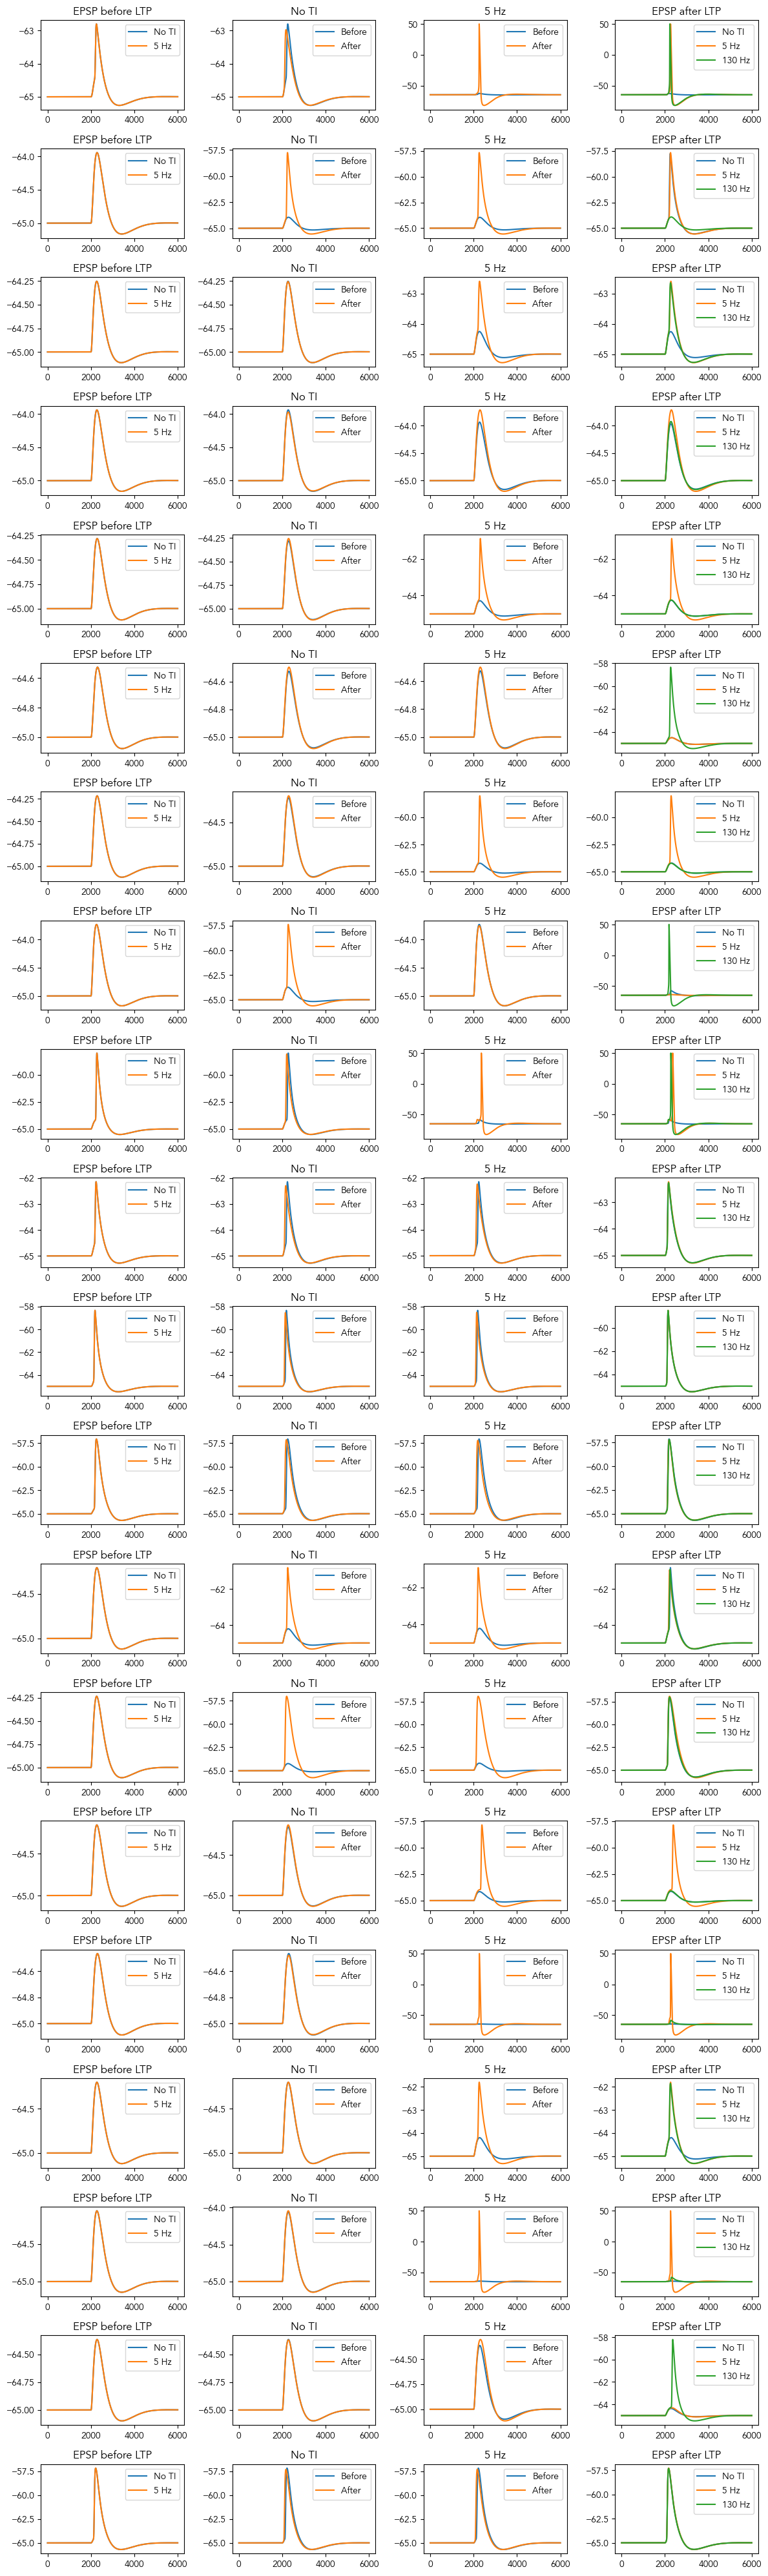

In [63]:
fig, axs = plt.subplots(nrows = len(idxs), ncols = 4, figsize = (12, len(idxs) * 2))

for i, idx in enumerate(idxs):
    try:
        voltage = pd.read_csv(f"output/temporal-interference/subthreshold_conductance_ltp_trace2/{idx}/voltage.csv")
        voltage5 = pd.read_csv(f"output/temporal-interference/subthreshold_conductance_ltp_trace_5Hz2/{idx}/voltage.csv")
        voltage130 = pd.read_csv(f"output/temporal-interference/subthreshold_conductance_ltp_trace_130Hz2/{idx}/voltage.csv")
    
        after_time = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
    
        epsp_before = voltage.Voltage[
            np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
        ].tolist()
        epsp_before_5 = voltage5.Voltage[
            np.logical_and(voltage5.Time > test_stimulus_1 - time_before, voltage5.Time < test_stimulus_1 + time_after)
        ].tolist()
    
        epsp_after = voltage.Voltage[after_time].tolist()
        epsp_after_5 = voltage5.Voltage[after_time].tolist()
        epsp_after_130 = voltage130.Voltage[after_time].tolist()
        
        axs[i][0].plot(
            epsp_before,
            label = "No TI"
        )
        axs[i][0].plot(
            epsp_before_5,
            label = "5 Hz"
        )
        axs[i][0].legend()
        axs[i][0].set_title("EPSP before LTP")
    
        axs[i][1].plot(
            epsp_before,
            label = "Before"
        )
        axs[i][1].plot(
            epsp_after,
            label = "After"
        )
        axs[i][1].legend()
        axs[i][1].set_title("No TI")
    
        axs[i][2].plot(
            epsp_before_5,
            label = "Before"
        )
        axs[i][2].plot(
            epsp_after_5,
            label = "After"
        )
        axs[i][2].legend()
        axs[i][2].set_title("5 Hz")
    
        axs[i][3].plot(
            epsp_after,
            label = "No TI"
        )
        axs[i][3].plot(
            epsp_after_5,
            label = "5 Hz"
        )
        axs[i][3].plot(
            epsp_after_130,
            label = "130 Hz"
        )
        axs[i][3].legend()
        axs[i][3].set_title("EPSP after LTP")
    except:
        print("whoops")
    
fig.tight_layout()
plt.show()

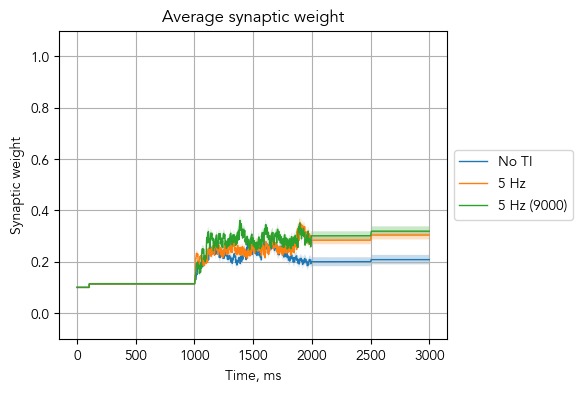

In [75]:
plt.show()
plt.figure(figsize = (5, 4))

types = {
    "No TI": "subthreshold_conductance_ltp_trace2",
    # "TI 0 Hz": "subthreshold_conductance_ltp_trace_0Hz2",
    "5 Hz": "subthreshold_conductance_ltp_trace_5Hz2",
    "5 Hz (9000)": "subthreshold_conductance_ltp_trace_5Hz_9000"
    # "130 Hz": "subthreshold_conductance_ltp_trace_130Hz2"
}

for type in types.keys():
    filename = types.get(type)
    weights = []
    time = []

    for idx in idxs:
        try:
            synapse_weights = pd.read_csv(f"output/temporal-interference/{filename}/{idx}/synapse_weights.csv", index_col = 0)
            synapses = [f"Synapse{i}" for i in range(0, 10)]

            idx_weights = np.array([synapse_weights[synapse] for synapse in synapses])
            weights.append(idx_weights)
            time = synapse_weights.Time
        except:
            print(f"whoops for {idx}")

    weights = np.concatenate(weights)

    mean = weights.mean(axis = 0)
    error = weights.std(axis = 0) / np.sqrt(weights.shape[0]) # SEM

    plt.plot(time, mean, linewidth = 1, label = type)
    plt.fill_between(time, mean - error, mean + error, alpha = 0.25)

plt.ylim(-0.1, 1.1)
plt.title("Average synaptic weight")
plt.xlabel("Time, ms")
plt.ylabel("Synaptic weight")
plt.legend(loc = "center left", bbox_to_anchor = (1, 0.5))
plt.grid()

plt.show()

run all at 100% EF strength

10, 40, 80 Hz poisson
10 seconds

no TI, TI with carrier only, TI 5 Hz, TI 130 Hz

